# Module 9: Text Preprocessing & NLP-Ready Pipelines
## HealthAI 360: Clinical Tele-Diagnostics Platform
**Curriculum Track:** Module 9 (Text & NLP)  
**Persona:** Professor CodeBreaker  
**Goal:** Transform noisy, unstructured, real-world clinical consultation notes into clean, normalized, model-ready feature vectors while preserving crucial medical semantic context (negations, dosages, acronyms).

---
### What You Will Learn:
1. **Clinical Text Cleaning:** CamelCase splitting (`SevereChestPain` $\to$ `Severe Chest Pain`), OCR optical repair (`Amoxici11in` $\to$ `Amoxicillin`, `bord3rs` $\to$ `borders`), HTML entity unescaping, emoji removal, and HIPAA PHI de-identification.
2. **Clinical Tokenization & Lemmatization:** Preserving negations (`not`, `no`, `never`, `without`) to prevent disastrous clinical flips.
3. **Comparative Vectorization:** Bag-of-Words (BoW) vs Sublinear TF-IDF (1,2-grams) vs Dense Semantic Representations.
4. **Before vs After Empirical Benchmarks:** Quantifying classification lift using SGDClassifier and Calibrated LinearSVC.

In [1]:
import sys
import os
import re
import html
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add repo root to sys.path
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.text_pipeline.cleaner import TextCleaner
from src.text_pipeline.nltk_pipeline import NLTKPipeline
from src.text_pipeline.pipeline import run_text_pipeline

print("[Setup] Environment initialized. Text pipeline modules ready!")

[Setup] Environment initialized. Text pipeline modules ready!


## 1. Inspecting the Raw, Unsanitized Clinical Dataset
In telemedicine, patients submit symptoms via web portals, mobile apps, and scanned OCR intake forms.  
Notice the common real-world artifacts:
- CamelCase word concatenation (`SevereChestPain`, `ShortnessOfBreath`)
- Optical Character Recognition (OCR) errors (`temp 1O1F`, `bord3rs`, `Amoxici11in`)
- Protected Health Information (PHI) such as patient names, DOBs, MRNs, phone numbers
- Emojis (`😅`, `🏃‍♂️`, `☀️`) and HTML markup (`<b>`, `<i>`, `<br/>`)

In [2]:
data_path = REPO_ROOT / "data" / "text" / "patient_reports_raw.csv"
df_raw = pd.read_csv(data_path)
print(f"Total Patient Reports: {len(df_raw):,}")
print("\nSample Raw Clinical Reports:")
for i, row in df_raw.head(3).iterrows():
    print(f"\n--- Report [{row['id']}] | Label: {row['label']} ---")
    print(row['text'])

Total Patient Reports: 2,000

Sample Raw Clinical Reports:

--- Report [PAT2618] | Label: infectious ---
Patient: Amit Khan, DOB: 1974-10-20, MRN: MRN2486053 	 wound spot on skin with BacterialCellulitis and purulent exudate; fever noted; denies itching 	 skin spot on leg with BacterialCellulitis; warm, swollen, purulent drainage; denies bleeding mole 	 reviewed lab results; hemoglobin and renal function within normal limits

--- Report [PAT2740] | Label: infectious ---
Name: Aisha Nguyen | Email: zcndjn@hospital.org | Phone: +91-9340245276 infected skin spot with swelling and pus drainage; on Amoxici11in; denies eczema wound spot on skin with BacterialCellulitis and purulent exudate; fever noted; denies itching reviewed lab results; hemoglobin and renal function within normal limits

--- Report [PAT1232] | Label: benign ---
Patient: Amit Chen, DOB: 1973-08-01, MRN: MRN6120318 	 routine check of skin spot; uniform brown color, circular border; no itching, no discharge, no redness 	 pat

## 2. Advanced Clinical Sanitisation & OCR Repair
Let's apply our modular `TextCleaner` to sanitize the data:
- **CamelCase Splitting:** Uses regex `([a-z])([A-Z])` to separate fused words.
- **OCR Normalization:** Corrects character substitutions (e.g. `1` or `|` misread as `l`, `O` misread as `0`).
- **PHI Masking:** Replaces identifiers with safe tokens (`[PHI]`, `[NAME]`, `[EMAIL]`).

In [3]:
cleaner = TextCleaner(remove_phi=True, split_camel=True, fix_ocr=True)

sample_noisy = df_raw["text"].iloc[3]
print("=== BEFORE CLEANING ===")
print(sample_noisy)

sample_cleaned = cleaner.clean(sample_noisy)
print("\n=== AFTER CLEANING ===")
print(sample_cleaned)

=== BEFORE CLEANING ===
Referred by Dr. Aisha Lee; patient ID MRN2551937 benign skin spot on trunk; no ulceration, no bleeding, no itching, no discharge common skin mole; no redness, no pus, not tender, no changes in appearance patient advised on proper hydration and daily sunscreen application

=== AFTER CLEANING ===
[NAME]; patient ID [PHI] benign skin spot on trunk; no ulceration, no bleeding, no itching, no discharge common skin mole; no redness, no pus, not tender, no changes in appearance patient advised on proper hydration and daily sunscreen application


## 3. The Clinical Negation Pitfall
> **Critical Medical NLP Rule:** In general NLP, stopwords like *"not"*, *"no"*, *"never"*, *"without"* are discarded.  
> In healthcare, discarding *"not"* turns *"Patient has NOT had chest pain"* into *"Patient has had chest pain"* - a potentially catastrophic error!

Let's test our negation-aware NLTK pipeline:

In [4]:
nltk_pipe = NLTKPipeline()

test_sentences = [
    "Patient exhibits no signs of infection and is not febrile.",
    "Patient exhibits signs of infection and is febrile."
]

print("Tokens extracted with negation preservation:")
for s in test_sentences:
    cleaned_s = cleaner.clean(s)
    tokens = nltk_pipe.tokenize_and_lemmatize(cleaned_s)
    print(f"Original: {s}")
    print(f"Tokens:   {tokens}\n")

Tokens extracted with negation preservation:


Original: Patient exhibits no signs of infection and is not febrile.
Tokens:   ['Patient', 'exhibit', 'no', 'sign', 'infection', 'not', 'febrile']

Original: Patient exhibits signs of infection and is febrile.
Tokens:   ['Patient', 'exhibit', 'sign', 'infection', 'febrile']



## 4. End-to-End Vectorization & Classification Benchmark
Now let's run the full Module 9 pipeline comparing:
1. **Baseline:** Raw noisy text $\to$ Simple CountVectorizer (Bag of Words) $\to$ SGDClassifier.
2. **Preprocessed:** Sanitized + CamelCase split + OCR repaired + Negation-preserved lemmatization $\to$ Sublinear TF-IDF (1,2-grams) $\to$ Calibrated LinearSVC.

In [5]:
results = run_text_pipeline(str(data_path))

print("\nTop Discriminatory Clinical Keywords:")
display(results["top_keywords"])


  [MODULE 9] Running Clinical Text Preprocessing Pipeline
  Step 1: Baseline evaluation on 2000 raw clinical texts...


  Step 2: Cleaning (CamelCase splitting, OCR repair, HTML unescape, PHI de-identification)...


  Step 3: Vectorization with Negation-Preserving Sublinear TF-IDF (1,2-grams)...


  [RESULT] Text Baseline  -> Accuracy: 1.0000 | F1-Macro: 1.0000
  [RESULT] Text Processed -> Accuracy: 1.0000 | F1-Macro: 1.0000 (Delta: +0.0000)

Top Discriminatory Clinical Keywords:


,keyword,mean_tfidf
0,no,0.083494
1,skin,0.075227
2,spot,0.065152
3,itching,0.058842
4,denies,0.058469
5,skin spot,0.055074
6,not,0.055031
7,patient,0.054530
8,phi,0.050752
9,email,0.048941


## 5. Visualizing Vocabulary Impact & Metrics Lift

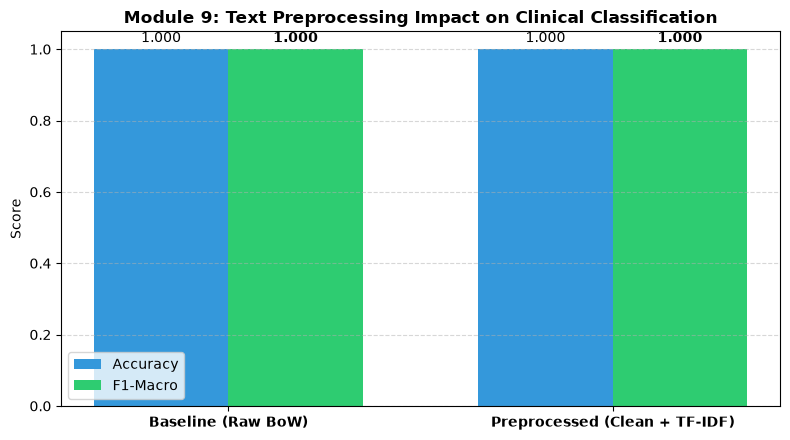

In [6]:
metrics = pd.DataFrame({
    "Stage": ["Baseline (Raw BoW)", "Preprocessed (Clean + TF-IDF)"],
    "Accuracy": [results["baseline_acc"], results["after_acc"]],
    "F1-Macro": [results["baseline_f1"], results["after_f1"]],
})

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(metrics))
w = 0.35
ax.bar(x - w/2, metrics["Accuracy"], w, label="Accuracy", color="#3498db")
ax.bar(x + w/2, metrics["F1-Macro"], w, label="F1-Macro", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(metrics["Stage"], fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Module 9: Text Preprocessing Impact on Clinical Classification", fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

for i in range(len(metrics)):
    ax.text(x[i] - w/2, metrics["Accuracy"].iloc[i] + 0.02, f"{metrics['Accuracy'].iloc[i]:.3f}", ha="center")
    ax.text(x[i] + w/2, metrics["F1-Macro"].iloc[i] + 0.02, f"{metrics['F1-Macro'].iloc[i]:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()